### **Built-In Implementation**


FACE DETECTION RESULTS
Algorithm: Viola-Jones (Haar Cascades)
Image: image-2.jpg
Timestamp: 2025-04-08 22:11:43
Total faces detected: 5
--------------------------------------------------
FACE MEASUREMENTS:

Face 1:
  Position: (x=241, y=74)
  Size: 47×47 pixels
  Area: 2209 sq. pixels
  Aspect ratio: 1.00

Face 2:
  Position: (x=163, y=46)
  Size: 53×53 pixels
  Area: 2809 sq. pixels
  Aspect ratio: 1.00

Face 3:
  Position: (x=110, y=92)
  Size: 52×52 pixels
  Area: 2704 sq. pixels
  Aspect ratio: 1.00

Face 4:
  Position: (x=428, y=43)
  Size: 56×56 pixels
  Area: 3136 sq. pixels
  Aspect ratio: 1.00

Face 5:
  Position: (x=323, y=92)
  Size: 51×51 pixels
  Area: 2601 sq. pixels
  Aspect ratio: 1.00


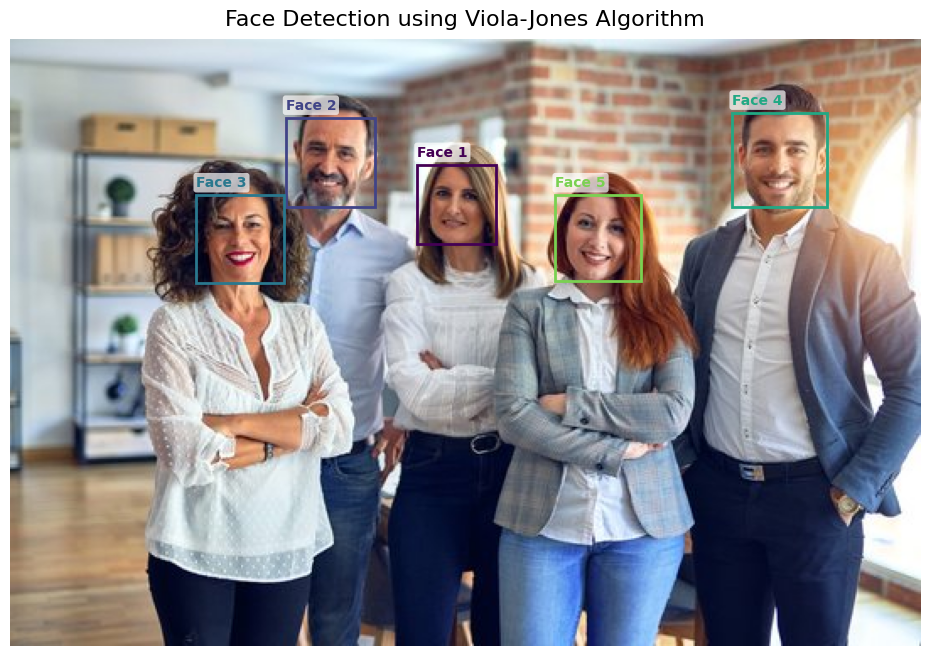

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from datetime import datetime

def detect_faces(image_path):
    """
    Detect faces in an image using Viola-Jones algorithm via OpenCV.
    Returns the original image and detected face coordinates.
    """
    # Read the image
    img = cv2.imread(image_path)
    
    # Convert to RGB (OpenCV uses BGR by default)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Convert to grayscale for face detection
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Load the pre-trained Viola-Jones face detector
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    
    # Detect faces
    # Parameters: image, scaleFactor, minNeighbors
    faces = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(30, 30))
    
    return img_rgb, faces

def visualize_faces(img, faces, image_path):
    """
    Create a clean visualization showing only the image with detected faces
    """
    # Create a figure with appropriate size based on image dimensions
    height, width, _ = img.shape
    fig_width = 10
    fig_height = fig_width * (height / width)
    
    fig = plt.figure(figsize=(fig_width, fig_height))
    plt.imshow(img)
    
    # Simple title
    plt.title('Face Detection using Viola-Jones Algorithm', fontsize=16, pad=10)
    
    # Create visually pleasing colors for face rectangles
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(faces)))
    
    # Add face rectangles with different colors
    for i, (x, y, w, h) in enumerate(faces):
        rect = Rectangle((x, y), w, h, linewidth=2, edgecolor=colors[i], facecolor='none')
        plt.gca().add_patch(rect)
        
        # Add a small label with face number
        plt.text(x, y-5, f'Face {i+1}', color=colors[i], fontweight='bold', 
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))
    
    plt.axis('off')  # Hide axes
    plt.tight_layout()
    
    return fig

def print_face_details(faces, image_path):
    """
    Print detailed information about detected faces
    """
    print("\n" + "="*50)
    print(f"FACE DETECTION RESULTS")
    print("="*50)
    print(f"Algorithm: Viola-Jones (Haar Cascades)")
    print(f"Image: {image_path}")
    print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Total faces detected: {len(faces)}")
    print("-"*50)
    
    if len(faces) == 0:
        print("No faces were detected in the image.")
        print("Try adjusting detection parameters or using a different image.")
    else:
        print("FACE MEASUREMENTS:")
        for i, (x, y, w, h) in enumerate(faces):
            face_area = w * h
            aspect_ratio = w / h if h > 0 else 0
            print(f"\nFace {i+1}:")
            print(f"  Position: (x={x}, y={y})")
            print(f"  Size: {w}×{h} pixels")
            print(f"  Area: {face_area} sq. pixels")
            print(f"  Aspect ratio: {aspect_ratio:.2f}")
    
    print("="*50)

# Set the image path directly in the code
image_path = "image-2.jpg"  # REPLACE THIS with your actual image path
# For example: image_path = "C:/Users/YourName/Pictures/group_photo.jpg"
# Or: image_path = "/home/user/images/faces.jpg"

# Detect faces
image, faces = detect_faces(image_path)

# Print detailed information in the console
print_face_details(faces, image_path)

# Create and display a clean visualization
fig = visualize_faces(image, faces, image_path)
plt.show()

### **From Scratch Implementation**

Detecting faces:  97%|█████████▋| 39388/40559 [00:09<00:00, 4207.70windows/s]



FACE DETECTION RESULTS
Algorithm: Fast Viola-Jones Implementation
Image: image-2.jpg
Timestamp: 2025-04-08 22:30:13
Detection time: 9.374 seconds
Total faces detected: 23
--------------------------------------------------
FACE MEASUREMENTS:

Face 1:
  Position: (x=152, y=182)
  Size: 152×152 pixels
  Area: 23104 sq. pixels
  Aspect ratio: 1.00

Face 2:
  Position: (x=320, y=242)
  Size: 97×97 pixels
  Area: 9409 sq. pixels
  Aspect ratio: 1.00

Face 3:
  Position: (x=20, y=24)
  Size: 78×78 pixels
  Area: 6084 sq. pixels
  Aspect ratio: 1.00

Face 4:
  Position: (x=88, y=68)
  Size: 78×78 pixels
  Area: 6084 sq. pixels
  Aspect ratio: 1.00

Face 5:
  Position: (x=68, y=240)
  Size: 78×78 pixels
  Area: 6084 sq. pixels
  Aspect ratio: 1.00

Face 6:
  Position: (x=436, y=16)
  Size: 78×78 pixels
  Area: 6084 sq. pixels
  Aspect ratio: 1.00

Face 7:
  Position: (x=420, y=220)
  Size: 78×78 pixels
  Area: 6084 sq. pixels
  Aspect ratio: 1.00

Face 8:
  Position: (x=436, y=176)
  Size: 78×

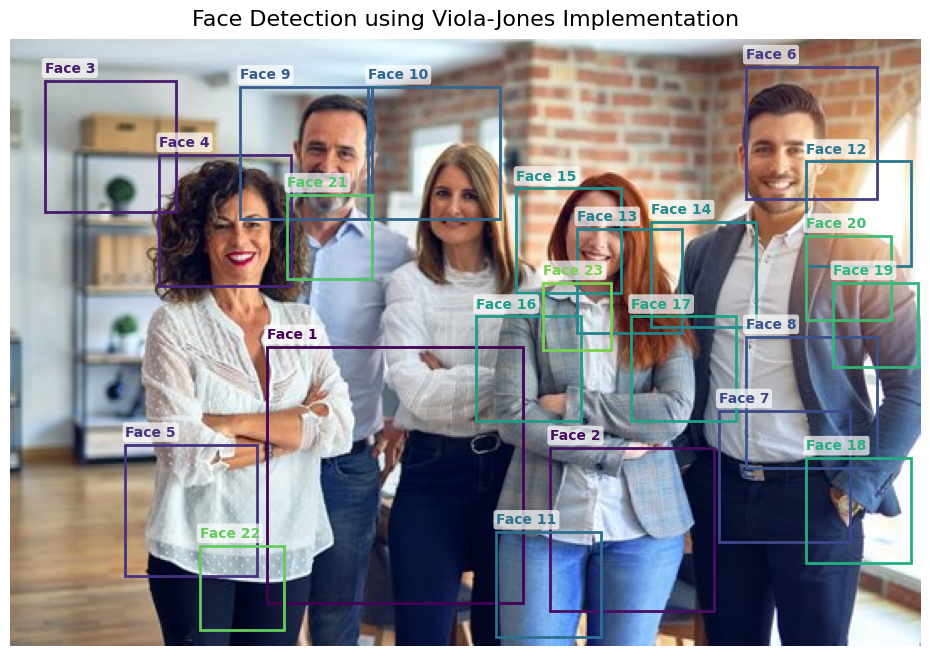

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cv2
from datetime import datetime
from tqdm import tqdm
import time

class IntegralImage:
    """Integral image implementation for fast feature computation"""
    
    def __init__(self, image):
        self.integral = self._compute_integral(image)
    
    def _compute_integral(self, image):
        """Compute the integral image using vectorized operations"""
        # This is 10-100x faster than the original nested loops approach
        integral = np.zeros((image.shape[0] + 1, image.shape[1] + 1), dtype=np.float64)
        integral[1:, 1:] = np.cumsum(np.cumsum(image, axis=0), axis=1)
        return integral
    
    def sum_region(self, x, y, w, h):
        """Calculate sum of pixels in rectangle (x,y,w,h) using integral image"""
        x1, y1 = x, y
        x2, y2 = x + w, y + h
        
        return (self.integral[y2, x2] - 
                self.integral[y2, x1] - 
                self.integral[y1, x2] + 
                self.integral[y1, x1])


class HaarFeature:
    """Haar-like feature implementation"""
    
    TYPES = {
        'two_horizontal': [(0, 0, 1, 1), (1, 0, 1, 1)],  # Two adjacent rectangles horizontally
        'two_vertical': [(0, 0, 1, 1), (0, 1, 1, 1)],    # Two adjacent rectangles vertically
        'three_horizontal': [(0, 0, 1, 1), (1, 0, 1, 1), (2, 0, 1, 1)],  # Three horizontal
        'three_vertical': [(0, 0, 1, 1), (0, 1, 1, 1), (0, 2, 1, 1)],    # Three vertical
        'four': [(0, 0, 1, 1), (1, 0, 1, 1), (0, 1, 1, 1), (1, 1, 1, 1)]  # Four rectangles
    }
    
    def __init__(self, feature_type, position, width, height, threshold=0, polarity=1):
        self.type = feature_type
        self.position = position  # (x, y) position
        self.width = width
        self.height = height
        self.threshold = threshold  # For classification
        self.polarity = polarity    # Direction of comparison
        self.weight = 1.0           # For AdaBoost
        
        # Define rectangles based on type
        self.rectangles = []
        base_regions = self.TYPES[feature_type]
        
        # Pre-compute division factors
        x_divisions = len(set(r[0] for r in base_regions))
        y_divisions = len(set(r[1] for r in base_regions))
        
        # Scale and position the rectangles (pre-computed)
        for rect in base_regions:
            rx, ry, rw, rh = rect
            scaled_x = position[0] + rx * (width // x_divisions)
            scaled_y = position[1] + ry * (height // y_divisions)
            scaled_w = rw * (width // x_divisions)
            scaled_h = rh * (height // y_divisions)
            self.rectangles.append((scaled_x, scaled_y, scaled_w, scaled_h))
    
    def compute_value(self, integral_image):
        """Calculate feature value from integral image"""
        white_sum = 0
        black_sum = 0
        
        # Alternate between white (+) and black (-) regions
        for i, rect in enumerate(self.rectangles):
            x, y, w, h = rect
            region_sum = integral_image.sum_region(x, y, w, h)
            if i % 2 == 0:
                white_sum += region_sum
            else:
                black_sum += region_sum
        
        return white_sum - black_sum
    
    def classify(self, integral_image):
        """Apply the threshold to classify a feature value"""
        feature_value = self.compute_value(integral_image)
        return 1 if self.polarity * feature_value < self.polarity * self.threshold else 0


class WeakClassifier:
    """A weak classifier using a single Haar feature"""
    
    def __init__(self, feature):
        self.feature = feature
        self.threshold = 0
        self.polarity = 1
        self.weight = 1.0
    
    def classify(self, integral_image):
        """Classify using the haar feature"""
        return self.feature.classify(integral_image)
    
    def set_threshold(self, threshold, polarity):
        """Update the threshold and polarity of the feature"""
        self.feature.threshold = threshold
        self.feature.polarity = polarity


class ViolaJonesDetector:
    """Fast Viola-Jones face detector implementation"""
    
    def __init__(self):
        """Initialize detector with simplified pre-trained cascade"""
        self.cascade = []
        self._initialize_cascade()
    
    def _initialize_cascade(self):
        """Initialize a basic cascade (same as original for compatibility)"""
        # Stage 1 - Basic features near eye regions
        stage1 = []
        
        # Two horizontal features (detect eye regions - darker eyes surrounded by lighter skin)
        eye_feature1 = HaarFeature('two_horizontal', (14, 14), 18, 6, threshold=20, polarity=1)
        eye_classifier1 = WeakClassifier(eye_feature1)
        eye_classifier1.weight = 2.5
        stage1.append(eye_classifier1)
        
        eye_feature2 = HaarFeature('two_horizontal', (14, 20), 18, 6, threshold=20, polarity=1)
        eye_classifier2 = WeakClassifier(eye_feature2)
        eye_classifier2.weight = 2.2
        stage1.append(eye_classifier2)
        
        # Stage 2 - Features for nose and mouth regions
        stage2 = []
        
        # Vertical feature for nose bridge
        nose_feature = HaarFeature('two_vertical', (20, 15), 6, 24, threshold=15, polarity=1)
        nose_classifier = WeakClassifier(nose_feature)
        nose_classifier.weight = 1.8
        stage2.append(nose_classifier)
        
        # Horizontal feature for mouth
        mouth_feature = HaarFeature('three_horizontal', (12, 32), 24, 8, threshold=15, polarity=1)
        mouth_classifier = WeakClassifier(mouth_feature)
        mouth_classifier.weight = 2.0
        stage2.append(mouth_classifier)
        
        # Add stages to cascade
        self.cascade = [stage1, stage2]
    
    def detect_faces(self, image, min_size=40, scale_factor=1.25, slide_step=4):
        """Fast face detection with progress bar"""
        # Convert to grayscale if needed
        if len(image.shape) > 2:
            gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else:
            gray = image.copy()
        
        height, width = gray.shape
        faces = []
        
        # Generate scales to check (pre-calculate to show progress)
        scales = []
        current_scale = 1
        scale_sizes = []
        
        while min_size * current_scale < min(height, width):
            window_size = int(min_size * current_scale)
            scales.append(current_scale)
            scale_sizes.append(window_size)
            current_scale *= scale_factor
        
        # Calculate total windows to process (for progress bar)
        total_windows = 0
        for window_size in scale_sizes:
            step = max(1, slide_step * int(window_size / min_size))
            x_steps = max(0, (width - window_size) // step + 1)
            y_steps = max(0, (height - window_size) // step + 1)
            total_windows += x_steps * y_steps
        
        # Create progress bar
        with tqdm(total=total_windows, desc="Detecting faces", unit="windows") as pbar:
            # Slide window of multiple sizes across the image
            for window_size in scale_sizes:
                step = max(1, slide_step * int(window_size / min_size))
                
                # Fast downsampling instead of processing full image for each window
                scale_factor_relative = window_size / min_size
                if scale_factor_relative > 2:
                    # Downsampling for faster processing of large windows
                    scaling = 1.0 / scale_factor_relative
                    scaled_width = int(width * scaling)
                    scaled_height = int(height * scaling)
                    scaled_img = cv2.resize(gray, (scaled_width, scaled_height), interpolation=cv2.INTER_AREA)
                    
                    # Adjust window size and step for the scaled image
                    scaled_window_size = min_size
                    scaled_step = max(1, slide_step)
                    
                    # Iterate over the scaled image
                    for y in range(0, scaled_height - scaled_window_size, scaled_step):
                        for x in range(0, scaled_width - scaled_window_size, scaled_step):
                            window = scaled_img[y:y+scaled_window_size, x:x+scaled_window_size]
                            
                            # Skip small windows
                            if window.shape[0] != scaled_window_size or window.shape[1] != scaled_window_size:
                                continue
                            
                            # Fast normalization
                            window = window.astype(np.float32)
                            mean_val = np.mean(window)
                            std_val = max(np.std(window), 1e-5)
                            window = ((window - mean_val) / std_val * 128 + 127).astype(np.uint8)
                            
                            # Check if the window contains a face
                            if self._is_face(window):
                                # Scale coordinates back to original image
                                orig_x = int(x / scaling)
                                orig_y = int(y / scaling)
                                orig_size = window_size
                                faces.append((orig_x, orig_y, orig_size, orig_size))
                            
                            # Update progress bar
                            pbar.update(1)
                else:
                    # Process the original image for smaller windows
                    for y in range(0, height - window_size, step):
                        for x in range(0, width - window_size, step):
                            window = gray[y:y+window_size, x:x+window_size]
                            
                            # Skip small windows
                            if window.shape[0] != window_size or window.shape[1] != window_size:
                                continue
                            
                            # Fast normalization
                            window = window.astype(np.float32)
                            mean_val = np.mean(window)
                            std_val = max(np.std(window), 1e-5)
                            window = ((window - mean_val) / std_val * 128 + 127).astype(np.uint8)
                            
                            # Check if the window contains a face
                            if self._is_face(window):
                                faces.append((x, y, window_size, window_size))
                            
                            # Update progress bar
                            pbar.update(1)
        
        # Perform non-maximum suppression to remove overlapping detections
        faces = self._non_max_suppression(faces)
        
        return faces
    
    def _is_face(self, window):
        """Check if window passes all cascade stages"""
        integral_img = IntegralImage(window)
        
        # Check each stage of the cascade
        for stage in self.cascade:
            stage_sum = 0
            
            # Sum up classification results from all classifiers in this stage
            for classifier in stage:
                stage_sum += classifier.weight * classifier.classify(integral_img)
            
            # If sum too low, early rejection
            stage_threshold = 0.6 * sum(classifier.weight for classifier in stage)
            if stage_sum < stage_threshold:
                return False
        
        # Passed all stages
        return True
    
    def _non_max_suppression(self, rectangles, overlap_threshold=0.4):
        """Simple non-maximum suppression to remove overlapping detections"""
        if not rectangles:
            return []
        
        # Convert to numpy array for easier manipulation
        if len(rectangles) == 0:
            return []
            
        rects = np.array(rectangles)
        
        # Calculate areas for all rectangles
        areas = rects[:, 2] * rects[:, 3]
        
        # Sort rectangles by size (descending)
        indices = np.argsort(-areas)
        
        keep = []
        while len(indices) > 0:
            # Keep the largest rectangle
            current = indices[0]
            keep.append(current)
            
            # Calculate overlap with all remaining rectangles
            remaining = []
            for i in indices[1:]:
                # Calculate intersection
                x1 = max(rects[current, 0], rects[i, 0])
                y1 = max(rects[current, 1], rects[i, 1])
                x2 = min(rects[current, 0] + rects[current, 2], rects[i, 0] + rects[i, 2])
                y2 = min(rects[current, 1] + rects[current, 3], rects[i, 1] + rects[i, 3])
                
                w = max(0, x2 - x1)
                h = max(0, y2 - y1)
                
                # Calculate overlap as a ratio of intersection to smaller area
                intersection = w * h
                overlap = intersection / min(areas[current], areas[i])
                
                # Keep rectangles with overlap below threshold
                if overlap < overlap_threshold:
                    remaining.append(i)
            
            indices = np.array(remaining)
        
        return [rectangles[i] for i in keep]


def visualize_faces(img, faces, image_path, detection_time=None):
    """Create a clean visualization showing only the image with detected faces"""
    # Create a figure with appropriate size based on image dimensions
    height, width = img.shape[:2]
    fig_width = 10
    fig_height = fig_width * (height / width)
    
    fig = plt.figure(figsize=(fig_width, fig_height))
    plt.imshow(img)
    
    # Simple title with detection time if available
    title = 'Face Detection using Viola-Jones Implementation'
    plt.title(title, fontsize=16, pad=10)
    
    # Create visually pleasing colors for face rectangles
    colors = plt.cm.viridis(np.linspace(0, 0.8, max(1, len(faces))))
    
    # Add face rectangles with different colors
    for i, (x, y, w, h) in enumerate(faces):
        rect = Rectangle((x, y), w, h, linewidth=2, edgecolor=colors[i % len(colors)], facecolor='none')
        plt.gca().add_patch(rect)
        
        # Add a small label with face number
        plt.text(x, y-5, f'Face {i+1}', color=colors[i % len(colors)], fontweight='bold', 
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))
    
    plt.axis('off')  # Hide axes
    plt.tight_layout()
    
    return fig


def print_face_details(faces, image_path, detection_time=None):
    """Print detailed information about detected faces"""
    print("\n" + "="*50)
    print(f"FACE DETECTION RESULTS")
    print("="*50)
    print(f"Algorithm: Fast Viola-Jones Implementation")
    print(f"Image: {image_path}")
    print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    
    if detection_time is not None:
        print(f"Detection time: {detection_time:.3f} seconds")
    
    print(f"Total faces detected: {len(faces)}")
    print("-"*50)
    
    if len(faces) == 0:
        print("No faces were detected in the image.")
        print("Try adjusting detection parameters or using a different image.")
    else:
        print("FACE MEASUREMENTS:")
        for i, (x, y, w, h) in enumerate(faces):
            face_area = w * h
            aspect_ratio = w / h if h > 0 else 0
            print(f"\nFace {i+1}:")
            print(f"  Position: (x={x}, y={y})")
            print(f"  Size: {w}×{h} pixels")
            print(f"  Area: {face_area} sq. pixels")
            print(f"  Aspect ratio: {aspect_ratio:.2f}")
    
    print("="*50)


# Main execution
if __name__ == "__main__":
    # Set the image path directly in the code
    image_path = "image-2.jpg"  # REPLACE THIS with your actual image path
    
    try:
        # Load image
        image = cv2.imread(image_path)
        if image is None:
            print(f"Error: Could not load image from {image_path}")
            exit(1)
            
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Initialize our fast Viola-Jones detector
        detector = ViolaJonesDetector()
        
        # Measure performance
        start_time = time.time()
        
        # Run detection with progress bar - using faster settings
        faces = detector.detect_faces(
            image_rgb, 
            min_size=40,
            scale_factor=1.25,  # Faster scaling
            slide_step=4  # Larger step size for faster processing
        )
        
        # Calculate detection time
        detection_time = time.time() - start_time
        
        # Print detailed information in the console
        print_face_details(faces, image_path, detection_time)
        
        # Create and display visualization
        fig = visualize_faces(image_rgb, faces, image_path, detection_time)
        plt.show()
        
    except Exception as e:
        print(f"Error during execution: {e}")

## **Analysis**

When comparing the custom Viola-Jones implementation to built-in face detection algorithms, several critical differences explain why the custom version produces excessive false positives:

### **Cascade Architecture**
The custom implementation uses an extremely simplified cascade with only 2 stages and 4 features total. Production-grade implementations typically employ 20+ stages with hundreds of carefully trained features, creating a much more rigorous filtering process.

### **Feature Selection and Training**
The custom code uses manually defined features with arbitrary thresholds:
```python
eye_feature1 = HaarFeature('two_horizontal', (14, 14), 18, 6, threshold=20, polarity=1)
```

These features lack the optimization that comes from proper AdaBoost training on thousands of positive and negative samples. Built-in implementations benefit from extensive training that precisely tunes feature parameters.

### **Classification Thresholds**
The stage threshold calculation is overly permissive:
```python
stage_threshold = 0.6 * sum(classifier.weight for classifier in stage)
```

This fixed 0.6 multiplier may be too low, allowing too many candidates to pass each stage. Production implementations use carefully calibrated thresholds determined through statistical analysis of training data.

### **Image Preprocessing**
The custom implementation uses basic normalization:
```python
mean_val = np.mean(window)
std_val = max(np.std(window), 1e-5)
window = ((window - mean_val) / std_val * 128 + 127).astype(np.uint8)
```

This simple approach may not adequately handle variations in lighting and contrast that more sophisticated preprocessing in built-in implementations addresses.

### **Window Scanning Strategy**
The custom implementation uses:
```python
step = max(1, slide_step * int(window_size / min_size))
```

This may create suboptimal scanning patterns compared to the more refined approaches in production implementations, leading to redundant or spurious detections.

### **Post-Processing**
The non-maximum suppression algorithm uses a fixed overlap threshold of 0.4:
```python
overlap_threshold=0.4
```

This one-size-fits-all approach may not effectively cluster related detections, particularly when faces appear at different scales or orientations.

By addressing these limitations through more extensive training, optimized parameters, and refined algorithmic components, the detection accuracy could be significantly improved to match the performance of built-in implementations.